In [ ]:
from chardet import detect
import pandas as pd

def get_encoding_type(file):
    with open(file, 'rb') as f:
        rawdata = f.read()
    return detect(rawdata)['encoding']


region_file = './maakunnat_pinta_alat.csv'
accident_file ='./koeti_riista_tau_001_fi.csv'

region = pd.read_csv(region_file, encoding=get_encoding_type(region_file))
accident = pd.read_csv(accident_file, encoding=get_encoding_type(accident_file))

In [4]:
print('Region dataset')
print(region.head())
print('Game dataset')
print(accident.head())

Region dataset
   id      gml_id  natcode               namefin              nameswe  \
0   1  1601110001        1               Uusimaa               Nyland   
1   2  1601110027       15             Pohjanmaa          Österbotten   
2   3  1601110035       19                 Lappi             Lappland   
3   4  1601110011        7           Päijät-Häme  Päijänne-Tavastland   
4   5  1601110037       21  Ahvenanmaan maakunta     Landskapet Åland   

          area  
0   9109841425  
1   7380547465  
2  94206757384  
3   5785648660  
4   1451696825  
Game dataset
   id                  tapahtumaAika  vuosi  kuukausi           x  \
0   1  2017-12-10T16:55:00.000+02:00   2017        12  278773.659   
1   2  2017-09-03T13:00:00.000+03:00   2017         9  397501.008   
2   3  2017-09-18T07:00:00.000+03:00   2017         9  418353.841   
3   4  2017-12-01T17:00:00.000+02:00   2017        12  488970.827   
4   5  2017-09-18T07:00:00.000+03:00   2017         9  418766.580   

             y  

So far we have only done pretty standard file reading.

# Cleaning
We should prune out the least occuring animals, since there is not enough data to teach on.

In [6]:
print("Species on the dataset")
print(accident['riistalajiNimi'].unique())

top_3_animals = accident['riistalajiNimi'].value_counts().nlargest(3).index

accident = accident[accident['riistalajiNimi'].isin(top_3_animals)]

print("Three most occuring species of the dataset")
print(accident['riistalajiNimi'].unique())

Species on the dataset
<StringArray>
['Metsäkauris', 'Hirvi', 'Valkohäntäpeura']
Length: 3, dtype: str
Three most occuring species of the dataset
<StringArray>
['Metsäkauris', 'Hirvi', 'Valkohäntäpeura']
Length: 3, dtype: str


# Merging

Next up is merging the area column from region dataset to the accident one, 
but first we have to edit the columns that we are going to use into uniform naming.

In [8]:

accident = accident.rename(columns={'maakuntaNimi': 'region'})
region = region.rename(columns={'namefin': 'region'})
df = pd.merge(accident, region[['region', 'area']], on='region', how='left')

df.head()

,id,tapahtumaAika,vuosi,kuukausi,x,y,kunta,kuntaNimi,maakunta,region,tielaji,tielajis,tieNumero,tieYllapito,tieYllapitoNimi,riistalaji,riistalajiNimi,area
0,1,2017-12-10T16:55:00.000+02:00,2017,12,278773.659,6980877.550,743,Seinäjoki,14,Etelä-Pohjanmaa,3,Valtatie,18.0,1.0,Valtio,47507,Metsäkauris,13864807779
1,2,2017-09-03T13:00:00.000+03:00,2017,9,397501.008,7503083.730,261,Kittilä,19,Lappi,4,Kantatie,80.0,1.0,Valtio,47503,Hirvi,94206757384
2,3,2017-09-18T07:00:00.000+03:00,2017,9,418353.841,7514104.657,261,Kittilä,19,Lappi,6,Muu maantie,9552.0,1.0,Valtio,47503,Hirvi,94206757384
3,4,2017-12-01T17:00:00.000+02:00,2017,12,488970.827,6722504.397,285,Kotka,8,Kymenlaakso,5,Seututie,357.0,1.0,Valtio,47629,Valkohäntäpeura,4622479273
4,5,2017-09-18T07:00:00.000+03:00,2017,9,418766.580,7506930.833,261,Kittilä,19,Lappi,6,Muu maantie,9552.0,1.0,Valtio,47503,Hirvi,94206757384


Regions finnish name is the common ground on these two datasets,
so we normalized that into uniform name and merged by it.

# Feature creation
After we pruned and topped up the dataset, 
we should add features that are helpful with teaching the model.

In [10]:

# Season feature
def get_season(month):
    if month in [12, 1, 2]:  return 'winter'
    elif month in [3, 4, 5]:  return 'spring'
    elif month in [6, 7, 8]:  return 'summer'
    else:                      return 'autumn'

df['tapahtumaAika'] = pd.to_datetime(df['tapahtumaAika'], utc=True)
df['tapahtumaAika'] = df['tapahtumaAika'].dt.tz_convert('Europe/Helsinki')
df['season'] = df['tapahtumaAika'].dt.month.map(get_season)

# Time of day feature
def time_of_day(hour):
    if 5 <= hour < 10:   return 'morning'
    elif 10 <= hour < 15: return 'midday'
    elif 15 <= hour < 21: return 'evening'
    else:                 return 'night'

df['hour'] = df['tapahtumaAika'].dt.hour
df['time_of_day'] = df['hour'].map(time_of_day)

# Weekend boolean value starting from after friday commute hours.
df['weekday'] = df['tapahtumaAika'].dt.weekday
def is_weekend(row):
    if row['weekday'] in [5, 6]:
        return 1
    elif row['weekday'] == 4 and row['hour'] >= 17:
        return 1
    else:
        return 0

df['is_weekend'] = df.apply(is_weekend, axis=1)

# Heuristic splitting of zones by the coordinates.

# latitude cutting points are taken from coordinates of Oulu and Tampere.
def lat_zone(y):
    if y < 6850000:    return 'south'
    elif y < 7200000:  return 'mid'
    else:               return 'north'

df['lat_zone'] = df['y'].map(lat_zone)

# longitudal cutting point is Jyväskylä
def lon_zone(x):
    if x < 443000:  return 'west'
    else:            return 'east'

df['lon_zone'] = df['x'].map(lon_zone)
df.columns.to_list()

['id',
 'tapahtumaAika',
 'vuosi',
 'kuukausi',
 'x',
 'y',
 'kunta',
 'kuntaNimi',
 'maakunta',
 'region',
 'tielaji',
 'tielajis',
 'tieNumero',
 'tieYllapito',
 'tieYllapitoNimi',
 'riistalaji',
 'riistalajiNimi',
 'area',
 'season',
 'hour',
 'time_of_day',
 'weekday',
 'is_weekend',
 'lat_zone',
 'lon_zone']

The features are now added, 
but there are now non numeric fields which needs to be encoded
and lots of redundant data that we are not going to feed to the model.

                 precision    recall  f1-score   support

          Hirvi       0.41      0.44      0.43      2294
    Metsäkauris       0.46      0.42      0.44      5644
Valkohäntäpeura       0.65      0.67      0.66      7903

       accuracy                           0.55     15841
      macro avg       0.51      0.51      0.51     15841
   weighted avg       0.55      0.55      0.55     15841



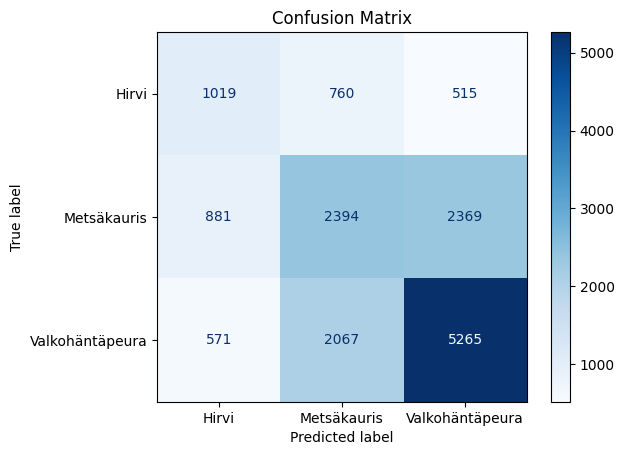

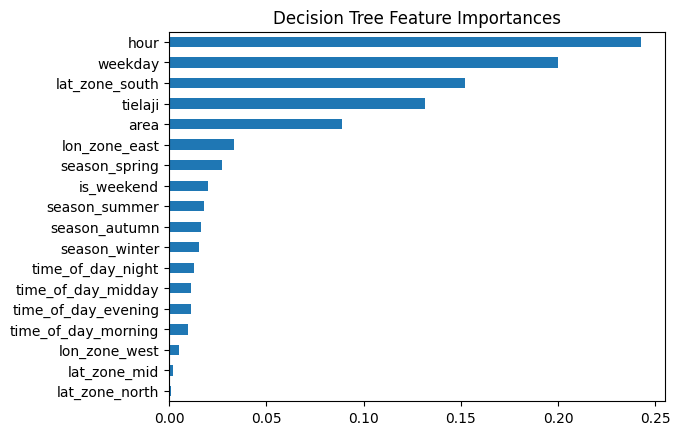

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Segregate numeric features and non-numeric ones.
categorical_cols = ['time_of_day', 'season', 'lat_zone', 'lon_zone']
numeric_features = ['hour', 'weekday', 'is_weekend', 'area', 'tielaji']

# One-hot encoding to non numeric values
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Find generated one-hot encoded column names and add them to complete list of features
one_hot_features = [col for col in df_encoded.columns if any(col.startswith(prefix + '_') for prefix in categorical_cols)]
feature_cols = numeric_features + one_hot_features

x = df_encoded[feature_cols]
y = LabelEncoder().fit_transform(df_encoded['riistalajiNimi'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

le = LabelEncoder().fit(df_encoded['riistalajiNimi'])
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

importance = pd.Series(dt.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh')

plt.title('Decision Tree Feature Importances')
plt.show()


The results of this model aren't that impressive.

                 precision    recall  f1-score   support

          Hirvi       0.56      0.43      0.48      2309
    Metsäkauris       0.58      0.34      0.43      5602
Valkohäntäpeura       0.65      0.88      0.75      7930

       accuracy                           0.62     15841
      macro avg       0.59      0.55      0.55     15841
   weighted avg       0.61      0.62      0.60     15841



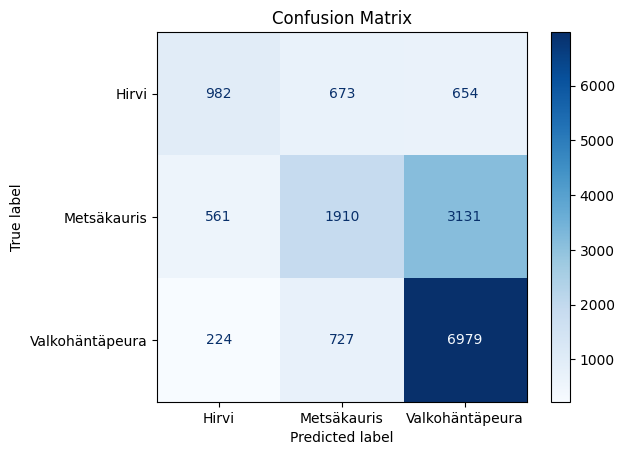

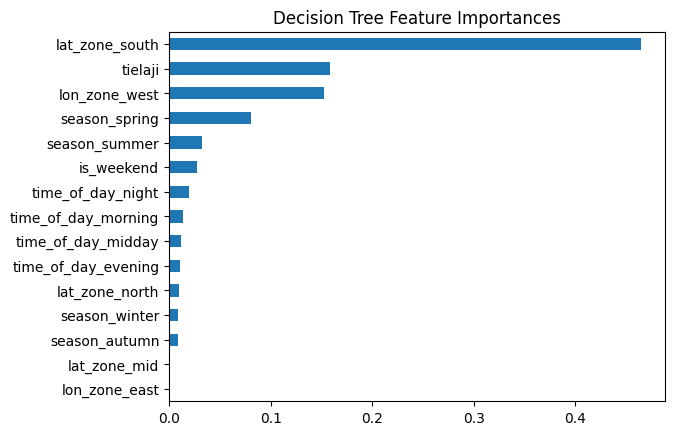

In [14]:


# cleaner set of features with noisy ones removed
categorical_cols = ['time_of_day', 'season', 'lat_zone', 'lon_zone']
numeric_features = ['is_weekend', 'tielaji']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

one_hot_features = [col for col in df_encoded.columns if any(col.startswith(prefix + '_') for prefix in categorical_cols)]
feature_cols = numeric_features + one_hot_features

x = df_encoded[feature_cols]
y = LabelEncoder().fit_transform(df_encoded['riistalajiNimi'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

importance = pd.Series(dt.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh')

plt.title('Decision Tree Feature Importances')
plt.show()


We deleted columns with overlapping data or non relevat data like area of the municipality
and gained ~10% more accuaracy for the model.
Hour was the most important feature but we added the time of day columns and they ease the confusion.
Area was also in the top features, but I think it adds guess work since its not really relevant data to decision.

Data is biased towards Valkohäntäpeura which makes it hard to make correct predictions.
Atleast it spots them well.

                 precision    recall  f1-score   support

          Hirvi       0.45      0.61      0.51      2309
    Metsäkauris       0.54      0.31      0.40      5602
Valkohäntäpeura       0.67      0.79      0.72      7930

       accuracy                           0.60     15841
      macro avg       0.55      0.57      0.55     15841
   weighted avg       0.59      0.60      0.58     15841



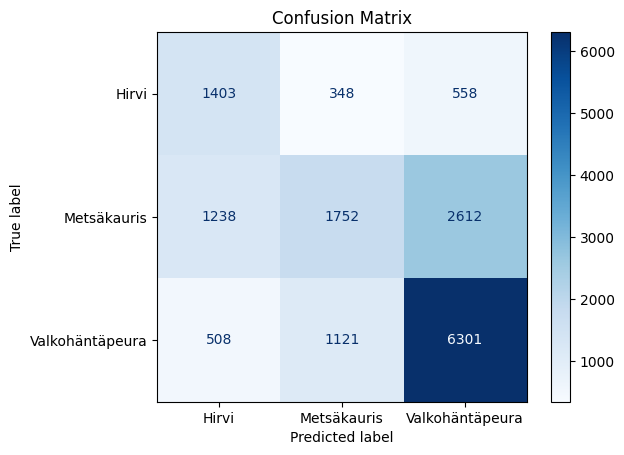

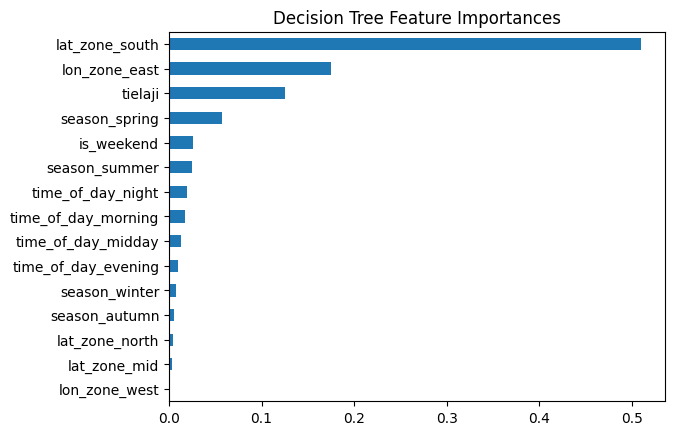

In [15]:

dt = DecisionTreeClassifier(class_weight='balanced')
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

importance = pd.Series(dt.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh')

plt.title('Decision Tree Feature Importances')
plt.show()


As a final bonus I tried to fight the data imbalance with using class_weight='balanced',
to punish more on wrong guesses and by that way make it more precise,
but it seems to make things worse by all metrics, except hirvi F1.
There is strong overlap in Metsäkauris and Valkohäntäpeura, so they are hard to distinct.